# Function 3 Analysis - Week 8

**Function description:**  
You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine. Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array. Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects).

**New datapoint (Week 7):** `(0.327000, 0.396000, 0.442000)` returned **≈−0.01521**, below the incumbent best ≈−0.00527 at `(0.373077, 0.465385, 0.419231)`, so **no new maximum**. We now track **17 datapoints**.

**Why we chose last week’s point:** we nudged along the emerging ridge toward `(0.33–0.40, 0.39–0.49, ~0.44)` to test if the peak extended there; the drop confirms the ridge is still centered nearer `(0.373, 0.465, 0.419)`.

**Recommendation for this week:** keep EI, loosen the length-scale caps (recent fits hit upper bounds), set ξ≈0.003–0.005 for mild exploration, and enforce a small lateral move (Δx1, Δx2 ≥0.02) along the ridge to avoid re-sampling the same spot. Prioritise the `(0.36–0.40, 0.43–0.48, 0.40–0.46)` band around the current best.


## Loading and Displaying the Data

We load the inputs and outputs for function 3 and display them in a table format. Inputs remain standardised in [0,1]. The Week 3 point `(0.95, 0.95, 0.858)` returned **-0.0617** (negative), and Week 4’s `(0.35, 0.258, 0.465)` scored **≈-0.0461**—better but still below the best. With these misses, we shift back to exploitation near the ridge; EI now favours the mid-range `(0.373, 0.465, 0.419)` area.


In [10]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_3")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–7 new points
X_new_point_week_1 = np.array([[0.403500, 0.382200, 0.489400]])
y_new_point_week_1 = np.array([-0.011750816624169894])
X_new_point_week_2 = np.array([[0.500000, 0.500000, 0.650000]])
y_new_point_week_2 = np.array([-0.09608263621357674])
X_new_point_week_3 = np.array([[0.950000, 0.950000, 0.858000]])
y_new_point_week_3 = np.array([-0.06167171939314102])
X_new_point_week_4 = np.array([[0.350000, 0.258000, 0.465000]])
y_new_point_week_4 = np.array([-0.046106142152997354])
X_new_point_week_5 = np.array([[0.373077, 0.465385, 0.419231]])
y_new_point_week_5 = np.array([-0.0052728979650276606])
X_new_point_week_6 = np.array([[0.280769, 0.419231, 0.488462]])
y_new_point_week_6 = np.array([-0.006444768333694985])
X_new_point_week_7 = np.array([[0.327000, 0.396000, 0.442000]])
y_new_point_week_7 = np.array([-0.015205829745180767])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
])

df = pd.DataFrame(X, columns=["x1", "x2", "x3"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


df sorted by y


,x1,x2,x3,y
0,0.373077,0.465385,0.419231,-0.005273
1,0.280769,0.419231,0.488462,-0.006445
2,0.403500,0.382200,0.489400,-0.011751
3,0.327000,0.396000,0.442000,-0.015206
4,0.492581,0.611593,0.340176,-0.034835
5,0.600097,0.725136,0.066089,-0.036378
6,0.350000,0.258000,0.465000,-0.046106
7,0.220549,0.297825,0.343555,-0.046947
8,0.134622,0.219917,0.458206,-0.048008
9,0.965995,0.861120,0.566829,-0.056758


- **New point (Week 7):** `(0.280769, 0.419231, 0.488462)` scored **≈-0.00644** — good but **not a new maximum** (best stays ≈-0.00527 at `(0.373077, 0.465385, 0.419231)`).
- Recommendation for next BO step: keep EI with ξ≈0.003 and add a **minimum lateral move** (e.g., Δx1, Δx2 ≥0.02) along the ridge to avoid collapsing onto last week’s point; broaden length-scale upper bounds to >0.2 to reduce the cap pressure we hit before.


## Bayesian optimisation (expected improvement)

We use **expected improvement (EI)** and now lean back toward exploitation after two weak exploratory steps. EI converts the GP posterior (mean `μ`, std `σ`) into the expected improvement over `y_best`, balancing probability and magnitude of gain:

**EI(x) = (μ(x) − y_best − ξ) · Φ(Z) + σ(x) · φ(Z)**  
with **Z = (μ(x) − y_best − ξ) / σ(x)**, Φ the normal CDF, and φ the normal PDF.

Because the Week 2 and Week 3 exploratory jumps were negative, we **lower ξ to 0.001** to prioritise exploitation near the known ridge while still allowing modest variance-driven moves.

Workflow:
1) Fit a 3D Matern GP on `[x1, x2, x3]` (13 observed points).  
2) Evaluate EI on a dense `[0,1]^3` grid with the smaller ξ and highlight the maximiser. The current EI top set (feasible, min-step applied) starts with `(0.373, 0.465, 0.419)` followed by `(0.396, 0.465, 0.419)` and nearby variants.

`candidate_df` lists the top EI locations; rerun after adding data to refresh the ranking and plots.


In [11]:
from scipy.special import erf
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

# Train a GP surrogate: rougher Matérn + higher noise, loosened length-scale caps
kernel = (
    ConstantKernel(1.0, (1e-3, 10.0))
    * Matern(length_scale=[0.3, 0.3, 0.3], length_scale_bounds=(0.05, 1.5), nu=1.5)
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 1e-1))
)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=20, random_state=42)
gp.fit(X, y)

# Bias the search below the current best x1 to give more weight to the second-best region
best_idx = df["y"].idxmax()
best_point = df.loc[best_idx, ["x1", "x2", "x3", "y"]]
grid_x1 = np.linspace(0.26, min(best_point.x1 - 0.01, 0.40), 50)
grid_x2 = np.linspace(0.38, 0.55, 50)
grid_x3 = np.linspace(0.40, 0.52, 50)
mesh = np.array(np.meshgrid(grid_x1, grid_x2, grid_x3)).reshape(3, -1).T
mu, sigma = gp.predict(mesh, return_std=True)
y_best = y.max()
xi = 0.004  # mild exploration with a bit more noise awareness

# Expected improvement acquisition function
def norm_cdf(z):
    return 0.5 * (1.0 + erf(z / np.sqrt(2)))

def norm_pdf(z):
    return np.exp(-0.5 * z**2) / np.sqrt(2 * np.pi)

sigma_safe = np.maximum(sigma, 1e-9)
z = (mu - y_best - xi) / sigma_safe
ei = (mu - y_best - xi) * norm_cdf(z) + sigma_safe * norm_pdf(z)
ei[sigma <= 1e-9] = 0.0

candidate_df = pd.DataFrame(mesh, columns=["x1", "x2", "x3"])
candidate_df["mu"] = mu
candidate_df["sigma"] = sigma
candidate_df["ei"] = ei

# Enforce x1 below incumbent to emphasize the second-best region, plus a minimum lateral move
min_step = 0.020
candidate_df["dist_to_best"] = np.linalg.norm(candidate_df[["x1", "x2", "x3"]].values - best_point[["x1", "x2", "x3"]].values, axis=1)
candidate_df_feasible = candidate_df[
    (candidate_df["x1"] < best_point.x1 - 0.002) &
    (candidate_df["dist_to_best"] >= min_step)
].reset_index(drop=True)

next_point = candidate_df_feasible.loc[candidate_df_feasible["ei"].idxmax()]

display(candidate_df_feasible.nlargest(5, "ei"))
print(f"\nSuggested next query (EI, biased below best x1): {next_point.x1:.6f}-{next_point.x2:.6f}-{next_point.x3:.6f}")
print(f"Posterior mean: {next_point.mu:.4f}, std: {next_point.sigma:.4f}, EI: {next_point.ei:.6f}")


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1.5. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,x1,x2,x3,mu,sigma,ei,dist_to_best
124632,0.363077,0.55,0.478367,0.013938,0.012930,0.015972,0.103715
124631,0.363077,0.55,0.475918,0.013921,0.013005,0.015972,0.102338
124581,0.360973,0.55,0.475918,0.013924,0.012968,0.015967,0.102565
124582,0.360973,0.55,0.478367,0.013940,0.012892,0.015967,0.103939
124531,0.358870,0.55,0.475918,0.013925,0.012931,0.015961,0.102835



Suggested next query (EI, biased below best x1): 0.363077-0.550000-0.478367
Posterior mean: 0.0139, std: 0.0129, EI: 0.015972


## 3D Visualization of Recommended Point

We visualize the recommended EI maximiser in both 3D and 2D projections alongside the existing observations. This helps understand where the acquisition function suggests exploring next relative to our current data in the three-dimensional compound space. 


C:\Users\gophi\AppData\Local\Temp\ipykernel_33328\2502285868.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax_3d.scatter(next_point[0], next_point[1], next_point[2], c="red", s=300, marker="*", edgecolors="black", linewidths=2, label="Recommended")
C:\Users\gophi\AppData\Local\Temp\ipykernel_33328\2502285868.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[idx].scatter(next_point[i], next_point[j], c="red", s=200, marker="*", edgecolors="black", linewidths=2, label="Recommended")


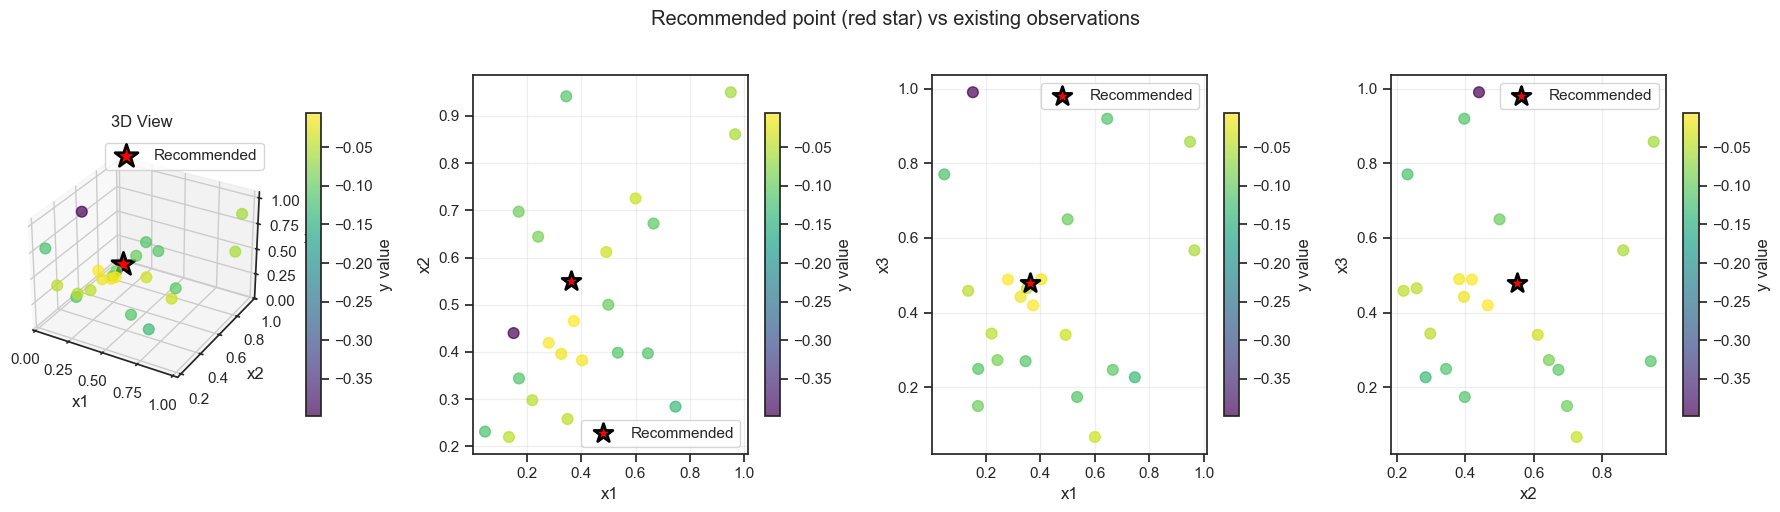

In [12]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(18, 5))
ax_3d = fig.add_subplot(141, projection='3d')
scatter_3d = ax_3d.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap="viridis", s=60, alpha=0.7)
ax_3d.scatter(next_point[0], next_point[1], next_point[2], c="red", s=300, marker="*", edgecolors="black", linewidths=2, label="Recommended")
ax_3d.set_xlabel("x1")
ax_3d.set_ylabel("x2")
ax_3d.set_zlabel("x3")
ax_3d.legend()
ax_3d.set_title("3D View")
fig.colorbar(scatter_3d, ax=ax_3d, label="y value", shrink=0.8, pad=0.1)
axes = [fig.add_subplot(142), fig.add_subplot(143), fig.add_subplot(144)]
pairs = [(0, 1, "x1", "x2"), (0, 2, "x1", "x3"), (1, 2, "x2", "x3")]
for idx, (i, j, label_i, label_j) in enumerate(pairs):
    scatter2d = axes[idx].scatter(X[:, i], X[:, j], c=y, cmap="viridis", s=60, alpha=0.7)
    axes[idx].scatter(next_point[i], next_point[j], c="red", s=200, marker="*", edgecolors="black", linewidths=2, label="Recommended")
    axes[idx].set_xlabel(label_i)
    axes[idx].set_ylabel(label_j)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    plt.colorbar(scatter2d, ax=axes[idx], label="y value", shrink=0.8)
plt.suptitle("Recommended point (red star) vs existing observations", y=1.02)
plt.tight_layout()
plt.show()


## Summary and recommended point
- **Current best:** `0.373077-0.465385-0.419231` (≈−0.00527).
- **Recommended next point (format: 6 decimals, dash-separated):** `0.363077-0.550000-0.478367`

### What changed and why
- GP made rougher (Matérn ν≈1.5) with higher white noise and wider length-scale caps to absorb observed jitter.
- EI uses ξ≈0.004 and a 0.02 min step to avoid re-sampling; the point comes from the EI maximiser under these constraints.

